Requested Citation Acknowledgment:
IEEE OTCBVS WS Series Bench; J. Davis and M. Keck, "A two-stage approach to person detection in thermal imagery," In Proc. Workshop on Applications of Computer Vision, January 2005

# Imports

In [2]:
### Object Detection with Faster R-CNN and RetinaNet in PyTorch - Template Code for Assignment 3 (2026 Spring) ###

### Might need to install the following packages if you haven't already: ###
### You can run these commands in your terminal or uncomment and run them in a notebook cell. ###
!pip -q install torch torchvision torchmetrics matplotlib
!pip install pandas
!pip install pycocotools
!pip install faster-coco-eval
!pip install tqdm

import re, random, time
from pathlib import Path
from typing import List, Dict, Tuple
import os

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm


import torch
from torch.utils.data import Dataset, DataLoader


import torchvision
from torchvision.transforms import functional as TF
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection import retinanet_resnet50_fpn_v2, fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection.mean_ap import MeanAveragePrecision


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 17.5 MB/s eta 0:00:00
Using device: cuda


# Data Preprocessing and creating data Loaders

In [4]:
### Helper function for loading and parsing the OSU Thermal Pedestrian Database (OTCBVS) ground-truth files. ###
### Needs to be adapted if you want to use a different dataset. ###


# OSU Thermal Pedestrian Database (OTCBVS) ground-truth parser
# File format:
#   NumberOfFrames
#   img_00001.bmp 4 (x1 y1 x2 y2) (x1 y1 x2 y2) ...
# Notes:
# - Coordinates are pixel indices in the original image (360x240).
# - We'll keep boxes in torchvision format: [x1, y1, x2, y2] (float32)

_BOX_RE = re.compile(r"\((\d+)\s+(\d+)\s+(\d+)\s+(\d+)\)")

def parse_groundtruth_txt(gt_path: str) -> Dict[str, torch.Tensor]:
    with open(gt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [
            ln.strip() for ln in f.readlines()
            if ln.strip() and not ln.strip().startswith("%")
        ]

    n_frames = int(lines[0])
    records = lines[1:1 + n_frames]

    out: Dict[str, torch.Tensor] = {}
    for ln in records:
        parts = ln.split()
        fname = parts[0]

        boxes = []
        for m in _BOX_RE.finditer(ln):
            x1, y1, x2, y2 = map(float, m.groups())
            # Safety: ensure proper ordering
            x1, x2 = min(x1, x2), max(x1, x2)
            y1, y2 = min(y1, y2), max(y1, y2)
            boxes.append([x1, y1, x2, y2])

        if boxes:
            out[fname] = torch.tensor(boxes, dtype=torch.float32)
        else:
            out[fname] = torch.zeros((0, 4), dtype=torch.float32)

    return out

In [ ]:
ds_path = os.path.join("Dataset","OSU_Thermal_Detection")
dir_list = os.listdir(ds_path)

#get ground truths and images
gts = []
images = []
for ds_dir in dir_list:
    gts.append(parse_groundtruth_txt(os.path.join(ds_path, ds_dir, "groundTruth.txt"))) #append dicts of boxes in images
    images.append(os.listdir(os.path.join(ds_path, ds_dir))) #append images

#remove conditions.txt and groundTruth.txt from images
for i in images:
    for idx, j in enumerate(i):
        if not j.startswith('img'):
            i.pop(idx)

In [21]:
#load and split data
def load_data(gts, imgs, sequences_to_load: list()):
    images, labels = list(), list() 
    for el in sequences_to_load:
        for f in imgs[el]:
            img = Image.open(os.path.join(ds_path, dir_list[el], f))
            images.append(TF.to_tensor(img))
            labels.append(gts[el][f])
    return images, labels

#here we split by sequence id (in other words by folder), selecting a few sequences for testing and evaluation, and leaving most for training
train_images, train_labels = load_data(gts, images, range(3, 10))
val_images, val_labels = load_data(gts, images, [0])
test_images, test_labels = load_data(gts, images, [1, 2])

In [22]:
#define dataset class and split datasets
class MyDataset(Dataset):
    def __init__(self, images, boxes):
        self.images = images
        self.boxes = boxes

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        boxes = self.boxes[idx].float()
        target = {'boxes': self.boxes[idx], 'labels': torch.ones((boxes.shape[0],), dtype=torch.int64)}
        return self.images[idx], target

In [23]:
train_ds = MyDataset(train_images, train_labels)
val_ds = MyDataset(val_images, val_labels)
test_ds = MyDataset(test_images, test_labels)

In [24]:
#define custom collator since there is a differing amount of bounding boxes per image
def collate_fn(batch):
    return tuple(zip(*batch))

#define dataloaders
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_fn)
test_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_fn)

# Visualize two samples of the Training Data

Total images found: 284
Sequence ids present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
train: 218 | Test: 42 | Val: 24


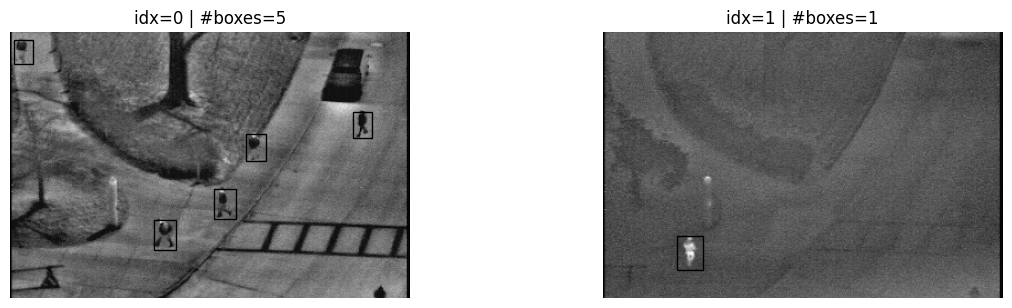

In [25]:
def visualize_samples(train_loader, n=2):
    images, labels = next(iter(train_loader))
    images, labels = images[:n], labels[:n]
    
    plt.figure(figsize=(12, 6))
    for i in range(n):
        img = images[i].squeeze(0)
        boxes = labels[i]['boxes'] #boxes
        
        ax = plt.subplot(2, 2, i+1)
        ax.imshow(img.cpu().numpy(), cmap="gray")
        ax.set_title(f"idx={i} | #boxes={boxes.size()[0]}")
        ax.axis("off")

        #draw boxes on images
        for box in boxes:
            x1, y1, x2, y2 = box.tolist() #upper left and lower right corners
            rt = patches.Rectangle(
                xy = (x1, y2), #lower left corner
                width = x2-x1,
                height = y1-y2,
                fill = False
            )
            ax.add_patch(rt)

    plt.tight_layout()
    plt.show()

print("Total images found:", sum([len(i) for i in gts]))
print("Sequence ids present:", [i for i, n in enumerate(gts)])
print(f"train: {len(train_ds)} | Test: {len(test_ds)} | Val: {len(val_ds)}")
visualize_samples(train_loader)

# Create the following methods for training and evaluation:
### 1.train_one_epoch
### 2.evaluate_map (mean Average Precision)
### 3.time_inference

In [26]:
def train_one_epoch(model, loader, optimizer, device, epoch=None):
    ### You Code Here ###
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, targets in loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad() #clear gradients

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward() #recurrence
        optimizer.step()

        running_loss += losses.item()

    return running_loss


@torch.no_grad()
def evaluate_map(model, loader, device):
    """mAP evaluation using torchmetrics.
    Returns a dict with keys like 'map', 'map_50', 'mar_100', ...
    """
    ### You Code Here ##
    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox"
    ).to(device)
    model.eval()
    metric.reset()
    for images, targets in loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        logits = model(images)
        metric.update(logits, targets)
    
    return metric.compute()


@torch.no_grad()
def time_inference(model, dataset, device, n_images=100, warmup=10):
    """Average inference time per image (ms)."""
    ### You Code Here ###
    model.eval()
    times = []

    #warmup
    for i, (images, _) in enumerate(dataset):
        images = images.to(device)
        _ = model([images])
        if i+1>=warmup:
            break
    
    #inference
    for i, (images, _) in enumerate(dataset):
        images = images.to(device)

        #synchronize if on cuda before and after to get more accurate times
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        logits = model([images])
        if device.type == "cuda":
            torch.cuda.synchronize()
        end = time.time()
        times.append(end-start)
        if i+1 >= n_images:
            break
        
    return float(np.mean(times)), float(np.std(times))


# Create Two-stage detector: Faster R-CNN (Region Proposal + classifier)

We'll fine-tune a Faster R-CNN model. To do this you will 
1- Load the fasterRCN.
2- Freeze the backbone.
3- create an optimizer for it. SGD with lr=0.005, momentum=0.9, weight_decay=0.0005

Note: In TorchVision detection models like Faster R-CNN, num_classes means: number of foreground categories + 1 background class

In [27]:
FRCNN = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1)
num_classes = 2 #number of classes, pedestrian (foreground) and background

#replace the classifier head so that it fits the dataset classes
in_features = FRCNN.roi_heads.box_predictor.cls_score.in_features
FRCNN.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#freeze backbone
for p in FRCNN.backbone.parameters():
    p.requires_grad = False

FRCNN.to(device)

#create optimizer
params = [p for p in FRCNN.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr = 0.005,
    momentum = 0.9,
    weight_decay = 0.0005
)

## Train for small number of epochs

In [28]:
epochs = 10
for epoch in range(1, epochs+1):
    print(f'Epoch {epoch}/{epochs}')
    loss = train_one_epoch(FRCNN, train_loader, optimizer, device, epoch)
    print('loss:', loss)

Epoch 1/10
loss: 14.216654643416405
Epoch 2/10
loss: 8.39519439637661
Epoch 3/10
loss: 5.906455159187317
Epoch 4/10
loss: 4.531344793736935
Epoch 5/10
loss: 4.044063039124012
Epoch 6/10
loss: 3.858496867120266
Epoch 7/10
loss: 3.4455665573477745
Epoch 8/10
loss: 3.321906588971615
Epoch 9/10
loss: 3.191552013158798
Epoch 10/10
loss: 3.0604810267686844


# Create One-stage detector: RetinaNet

We'll fine-tune RetinaNet. To do this you will:
1- Load the RetinaNet.
2- Freeze the backbone.
3- create an optimizer for it. SGD with lr=0.005, momentum=0.9, weight_decay=0.0005


Note: In TorchVision detection models, num_classes means: number of foreground categories + 1 background class


In [29]:
rtnet = retinanet_resnet50_fpn_v2(weights=RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1)
num_classes = 2 #number of classes, pedestrian (foreground) and background

#replace the classifier head so that it fits the dataset classes
in_features = rtnet.head.classification_head.conv[0][0].in_channels #amount of in_channels in first layer of classification head
num_anchors = rtnet.head.classification_head.num_anchors
rtnet.head.classification_head = RetinaNetClassificationHead(
    in_features,
    num_anchors,
    num_classes
)

#freeze backbone
for p in rtnet.backbone.parameters():
    p.requires_grad = False

rtnet.to(device)

#create optimizer
params = [p for p in rtnet.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr = 0.005,
    momentum = 0.9,
    weight_decay = 0.0005
)

In [30]:
epochs = 10
for epoch in range(1, epochs+1):
    print(f'Epoch {epoch}/{epochs}')
    loss = train_one_epoch(rtnet, train_loader, optimizer, device, epoch)
    print('loss:', loss)

Epoch 1/10
loss: 33.580398201942444
Epoch 2/10
loss: 24.98839944601059
Epoch 3/10
loss: 11.04041075706482
Epoch 4/10
loss: 8.963188916444778
Epoch 5/10
loss: 8.094669073820114
Epoch 6/10
loss: 7.578223884105682
Epoch 7/10
loss: 7.418846607208252
Epoch 8/10
loss: 6.8533307164907455
Epoch 9/10
loss: 6.739832550287247
Epoch 10/10
loss: 6.604081213474274


## Calculate val_mAP, val_mAP50, mean_infer_ms for both methods

In [31]:
def calculate_metrics(model):
    metrics = evaluate_map(model, val_loader, device)
    mean_times, std_times = time_inference(model, val_ds, device)
    mean_times = mean_times*1000 #time_inference returns seconds, so here we convert to ms
    return metrics['map'], metrics['map_50'], mean_times

FRCNN_metrics = calculate_metrics(FRCNN)
rtnet_metrics = calculate_metrics(rtnet)

print(f'FRCNN val_mAP:{FRCNN_metrics[0]} | val_mAP50: {FRCNN_metrics[1]} | mean_infer_ms: {FRCNN_metrics[2]}')
print(f'rtnet val_mAP:{rtnet_metrics[0]} | val_mAP50: {rtnet_metrics[1]} | mean_infer_ms: {rtnet_metrics[2]}')

FRCNN val_mAP:0.6551470756530762 | val_mAP50: 0.9571748971939087 | mean_infer_ms: 108.34362109502156
rtnet val_mAP:0.583996593952179 | val_mAP50: 0.9383917450904846 | mean_infer_ms: 61.6006056467692


## Visualize the results of two methods for couple of images from test set

In [32]:
def visualize_results(model, loader, n=4):
    images, labels = next(iter(loader))
    images, labels = images[:n], labels[:n]
    
    plt.figure(figsize=(12, 6))
    for i in range(n):
        img = images[i].squeeze(0)
        gt_boxes = labels[i]['boxes'] #ground truth boxes
        ax = plt.subplot(2, 2, i+1)
        ax.imshow(img.cpu().numpy(), cmap="gray")

        #get predictions
        pred = model([image.to(device) for image in images])[i]
        pred_boxes = pred['boxes']
        pred_scores = pred['scores']
        pred_amount = 0
        
        #draw gt boxes
        for box in gt_boxes:
            x1, y1, x2, y2 = box.tolist() #upper left and lower right corners
            rt = patches.Rectangle(
                xy = (x1, y2), #lower left corner
                width = x2-x1,
                height = y1-y2,
                fill = False,
                color='red'
            )
            ax.add_patch(rt)

        #draw pred boxes
        for j, box in enumerate(pred_boxes):
            if pred_scores[j] >= 0.6: #arbitrary score threshold to weed out unlikely predictions
                x1, y1, x2, y2 = box.tolist() #upper left and lower right corners
                rt = patches.Rectangle(
                    xy = (x1, y2), #lower left corner
                    width = x2-x1,
                    height = y1-y2,
                    fill = False,
                    color='cyan'
                )
                ax.add_patch(rt)
                pred_amount+=1
        
        ax.set_title(f"idx={i} | #gt_boxes={gt_boxes.size()[0]} | #pred_boxes={pred_amount}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

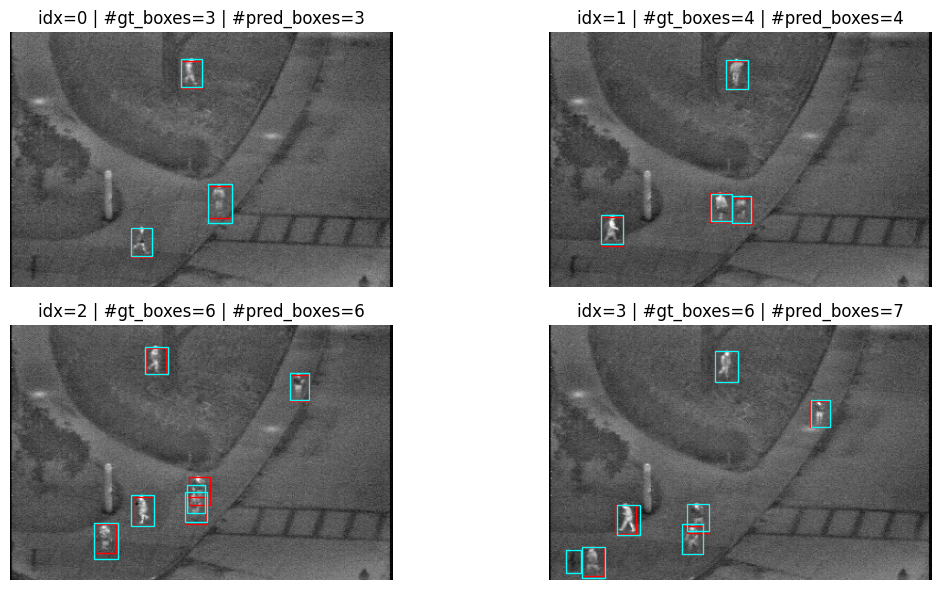

In [33]:
#results on FasterRCNN
visualize_results(FRCNN, test_loader)

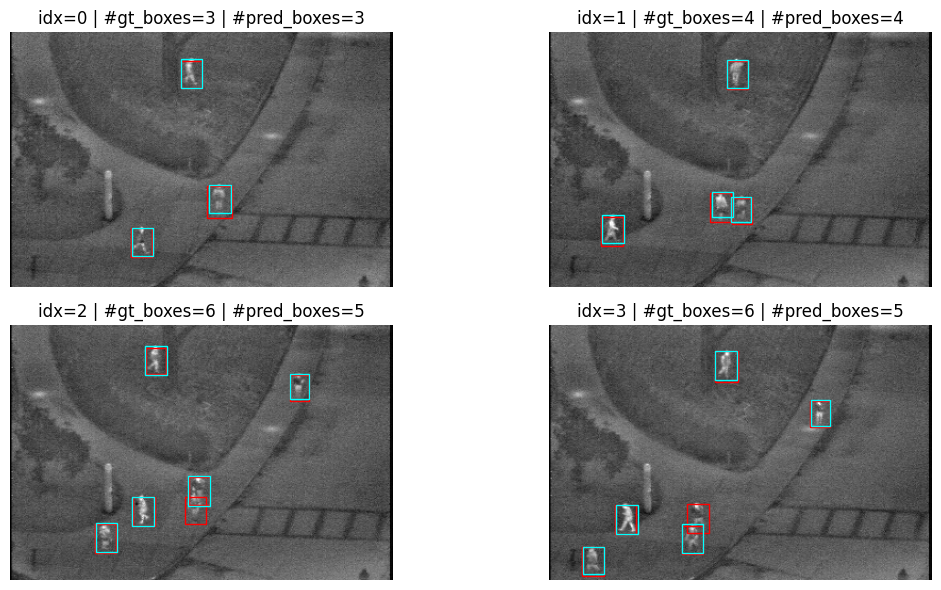

In [34]:
#results on Retinanet
visualize_results(rtnet, test_loader)

## write your conclusion  for the results you got

The results for the models were surprisingly good in my opinion, although without adding a score threshold there were some predictions that were off by quite a bit. I ran the code on kaggle with the GPU P100 accelerator with the mean inference times being ~108ms = 9-10fps for FasterRCNN and ~61ms = 16-17fps for RetinaNet, which was a bit better than I expected.

The other metrics, mAP and mAP_50, were about as follows:

- FasterRCNN: mAP:0.6551, mAP50: 0.9571
- Retinanet: mAP:0.5839, mAP50: 0.9383

With mAP50 being a somewhat lenient metric, requiring only 50% of area coverage for a prediction to be counted as correct, with mAP taking 50% as a minimum requirement and rewarding better alignment. Based on the last visualized results the models struggles with overlapping or close targets, or background elements that might slightly resemble a target. However some of the possible predictions were cut off according to score as mentioned, in which may have been some correct predictions as we can see when the Retinanet model visualized predictions failing to recognize a person overlapping with another.